# Tarea drug discovery

## Milena Fernanda Rivera Hernández

# Tarea relacionada a la aula de Chemberta

Los estudiantes deberan desarrollar un notebook en el cual utilicen los dados trabajados en clase (Ache_activity_IC50.csv) para crear un modelo de predicción para búsqueda de nuevos inhibidores del target mencionado.

Los estudiantes deben hacer cualquier tipo de pre-procesamiento de los datos y escoger un algoritmo (RF, SVM, etc). Puede ser escogido cualquier tipo de descriptores moleculares (propiedades moleculares, fingerprints, chemberta).

Pueden realizar clasificación o regresión. La precisión del modelo no será considerada para la evaluación, lo mas importante será el esquema de trabajo.



In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 11.1 MB/s eta 0:00:00


In [ ]:
import rdkit

In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR
from sklearn import svm
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit import DataStructs
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.Descriptors import MolWt
from rdkit.Chem.Descriptors import MolLogP
from rdkit.Chem.Descriptors import NumHAcceptors
from rdkit.Chem.Descriptors import NumHDonors
from rdkit.Chem import Lipinski
from rdkit.Chem import QED
from rdkit.Chem import MolSurf
from IPython.display import SVG # to use Scalar Vector Graphics (SVG) not bitmaps, for cleaner lines
from rdkit.Chem import Draw # to draw molecules
from rdkit.Chem.Draw import IPythonConsole # to draw inline in iPython
from rdkit.Chem import rdDepictor  # to generate 2D depictions of molecules
from rdkit.Chem.Draw import rdMolDraw2D # to draw 2D molecules using vectors
import seaborn as sns

# Preprocesamiento

In [ ]:
df=pd.read_csv('Ache_activity_IC50.csv', sep=";")
df.head()

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL345905,NaN,NaN,243.35,0.0,2.77,1B,CN1CCC(C[C@H]2Cc3ccccc3C2=O)CC1,IC50,'=',...,CHEMBL1126158,1,Scientific Literature,J Med Chem,1992.0,NaN,NaN,NaN,NaN,7.700
1,CHEMBL263322,NaN,NaN,271.40,0.0,3.55,10,CN1CCC(CCCC2Cc3ccccc3C2=O)CC1,IC50,'=',...,CHEMBL1126158,1,Scientific Literature,J Med Chem,1992.0,NaN,NaN,NaN,NaN,1.500
2,CHEMBL338492,NaN,NaN,208.28,0.0,2.12,35,CC(=O)Oc1ccc(C)c([N+](C)(C)C)c1,IC50,'=',...,CHEMBL1130277,1,Scientific Literature,J Med Chem,1997.0,NaN,NaN,NaN,NaN,5.273
3,CHEMBL93936,NaN,NaN,405.54,0.0,4.51,1j,c1ccc(CN2CCC(CCc3noc4cc(N5CCOCC5)ccc34)CC2)cc1,IC50,'=',...,CHEMBL1127437,1,Scientific Literature,J Med Chem,1994.0,NaN,NaN,NaN,NaN,0.800
4,CHEMBL440185,NaN,NaN,236.27,0.0,2.09,8 (table I),COc1cc2c(c(OC)c1OC)C(=O)C(C)C2,IC50,'=',...,CHEMBL1126157,1,Scientific Literature,J Med Chem,1992.0,NaN,NaN,NaN,NaN,7.880


In [ ]:
df.info() # contamos con 9415 entries

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9415 entries, 0 to 9414
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Molecule ChEMBL ID          9415 non-null   object 
 1   Molecule Name               1898 non-null   object 
 2   Molecule Max Phase          1505 non-null   float64
 3   Molecular Weight            9403 non-null   float64
 4   #RO5 Violations             9302 non-null   float64
 5   AlogP                       9302 non-null   float64
 6   Compound Key                9415 non-null   object 
 7   Smiles                      9379 non-null   object 
 8   Standard Type               9415 non-null   object 
 9   Standard Relation           8130 non-null   object 
 10  Standard Value              8130 non-null   float64
 11  Standard Units              8151 non-null   object 
 12  pChEMBL Value               6717 non-null   float64
 13  Data Validity Comment       717 n

In [ ]:
df['Standard Value']

,Standard Value
0,7.70
1,1.50
2,5333.35
3,0.80
4,13.18
...,...
9410,1900.00
9411,2600.00
9412,11300.00
9413,7943.28


In [ ]:
df['pChEMBL Value']

,pChEMBL Value
0,8.11
1,8.82
2,5.27
3,9.10
4,7.88
...,...
9410,5.72
9411,5.58
9412,4.95
9413,5.10


In [ ]:
# Quitamos todos los valores nulos
df = df.dropna(subset=['Standard Value', 'pChEMBL Value'])

# Aseguramos que todos sean numeric data
df['Standard Value'] = pd.to_numeric(df['Standard Value'], errors='coerce')
df['pChEMBL Value'] = pd.to_numeric(df['pChEMBL Value'], errors='coerce')

# Volvemos a eliminar filas con valores no numericos
df = df.dropna(subset=['Standard Value', 'pChEMBL Value'])
df.info() # contamos con 6717 entries

<class 'pandas.core.frame.DataFrame'>
Index: 6717 entries, 0 to 9413
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Molecule ChEMBL ID          6717 non-null   object 
 1   Molecule Name               902 non-null    object 
 2   Molecule Max Phase          680 non-null    float64
 3   Molecular Weight            6717 non-null   float64
 4   #RO5 Violations             6677 non-null   float64
 5   AlogP                       6677 non-null   float64
 6   Compound Key                6717 non-null   object 
 7   Smiles                      6716 non-null   object 
 8   Standard Type               6717 non-null   object 
 9   Standard Relation           6717 non-null   object 
 10  Standard Value              6717 non-null   float64
 11  Standard Units              6717 non-null   object 
 12  pChEMBL Value               6717 non-null   float64
 13  Data Validity Comment       0 non-null

<ipython-input-10-881242300>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Standard Value'] = pd.to_numeric(df['Standard Value'], errors='coerce')
<ipython-input-10-881242300>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pChEMBL Value'] = pd.to_numeric(df['pChEMBL Value'], errors='coerce')


In [ ]:
# Checamos que  no haya valores (NaN) en Smiles
df["Smiles"].isna().any()

# Filtramos
resultado = df.dropna(subset=['Smiles'])
resultado.info() # bajamos a 6716 entries

<class 'pandas.core.frame.DataFrame'>
Index: 6716 entries, 0 to 9413
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Molecule ChEMBL ID          6716 non-null   object 
 1   Molecule Name               901 non-null    object 
 2   Molecule Max Phase          680 non-null    float64
 3   Molecular Weight            6716 non-null   float64
 4   #RO5 Violations             6677 non-null   float64
 5   AlogP                       6677 non-null   float64
 6   Compound Key                6716 non-null   object 
 7   Smiles                      6716 non-null   object 
 8   Standard Type               6716 non-null   object 
 9   Standard Relation           6716 non-null   object 
 10  Standard Value              6716 non-null   float64
 11  Standard Units              6716 non-null   object 
 12  pChEMBL Value               6716 non-null   float64
 13  Data Validity Comment       0 non-null

In [ ]:
# Buscamos duplicados en Smiles
duplicatas = resultado[resultado.duplicated(subset=['Smiles'], keep=False)]
len(duplicatas) # 1811 duplicados

1811

In [ ]:
# Removemos duplicados manteniendo la primera ocurrencia
resultado = resultado.drop_duplicates(subset=['Smiles'])
resultado.info() #5383 entries


<class 'pandas.core.frame.DataFrame'>
Index: 5383 entries, 0 to 9412
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Molecule ChEMBL ID          5383 non-null   object 
 1   Molecule Name               216 non-null    object 
 2   Molecule Max Phase          95 non-null     float64
 3   Molecular Weight            5383 non-null   float64
 4   #RO5 Violations             5345 non-null   float64
 5   AlogP                       5345 non-null   float64
 6   Compound Key                5383 non-null   object 
 7   Smiles                      5383 non-null   object 
 8   Standard Type               5383 non-null   object 
 9   Standard Relation           5383 non-null   object 
 10  Standard Value              5383 non-null   float64
 11  Standard Units              5383 non-null   object 
 12  pChEMBL Value               5383 non-null   float64
 13  Data Validity Comment       0 non-null

In [ ]:
# Confirmamos duplicados en Smiles
duplicatas = resultado[resultado.duplicated(subset=['Smiles'], keep=False)]
len(duplicatas) # 0 duplicados

0

# Algoritmo

In [ ]:
# Trabajamos con las 5383 entries

resultado.loc[resultado['Standard Value'] > 501, 'Activity'] = 0 #inactives
resultado.loc[resultado['Standard Value'] <= 500, 'Activity'] = 1

In [ ]:
resultado['Activity'].value_counts()

,count
Activity,
0.0,3165
1.0,2218


# propiedades moleculares

In [ ]:
# Usando lo visto en clase para estandarizar
def standardize_mol(mol, verbose=False):
    """Standardize the RDKit molecule, select its parent molecule, uncharge it,
    then enumerate all the tautomers.
    If verbose is true, an explanation of the steps and structures of the molecule
    as it is standardized will be output."""
    # Follows the steps from:
    #  https://github.com/greglandrum/RSC_OpenScience_Standardization_202104/blob/main/MolStandardize%20pieces.ipynb
    # as described **excellently** (by Greg Landrum) in
    # https://www.youtube.com/watch?v=eWTApNX8dJQ -- thanks JP!

    from rdkit.Chem.MolStandardize import rdMolStandardize
    # removeHs, disconnect metal atoms, normalize the molecule, reionize the molecule
    clean_mol = rdMolStandardize.Cleanup(mol)
    if verbose:
        #print('Remove Hs, disconnect metal atoms, normalize the molecule, reionize the molecule:')
        draw_mol_with_SVG(clean_mol)

    # if many fragments, get the "parent" (the actual mol we are interested in)
    parent_clean_mol = rdMolStandardize.FragmentParent(clean_mol)
    if verbose:
        #print('Select the "parent" fragment:')
        draw_mol_with_SVG(parent_clean_mol)

    # try to neutralize molecule
    uncharger = rdMolStandardize.Uncharger() # annoying, but necessary as no convenience method exists
    uncharged_parent_clean_mol = uncharger.uncharge(parent_clean_mol)
    if verbose:
        #print('Neutralize the molecule:')
        draw_mol_with_SVG(uncharged_parent_clean_mol)

    # Note: no attempt is made at reionization at this step
    # nor ionization at some pH (RDKit has no pKa caculator);
    # the main aim to to represent all molecules from different sources
    # in a (single) standard way, for use in ML, catalogues, etc.
    te = rdMolStandardize.TautomerEnumerator() # idem
    taut_uncharged_parent_clean_mol = te.Canonicalize(uncharged_parent_clean_mol)
    if verbose:
        #print('Enumerate tautomers:')
        draw_mol_with_SVG(taut_uncharged_parent_clean_mol)
    assert taut_uncharged_parent_clean_mol != None

    if verbose: print("smile_stand:", Chem.MolToSmiles(taut_uncharged_parent_clean_mol))
    return taut_uncharged_parent_clean_mol


def standardize_smiles(smiles, verbose=False):
  """Standardize the SMILES string, select its parent molecule, uncharge it,
    then enumerate all the tautomers."""
  if verbose: print(smiles)
  std_mol = standardize_mol(Chem.MolFromSmiles(smiles), verbose=verbose)
  return Chem.MolToSmiles(std_mol)


def draw_mol_with_SVG(mol, molSize=(450,150)):
    """Use SVG to draw an RDKit molecule, mol."""
    mc = Chem.Mol(mol.ToBinary())
    if not mc.GetNumConformers():
        rdDepictor.Compute2DCoords(mc) # Compute 2D coordinates
    # Initialize the drawer with the size
    drawer = rdMolDraw2D.MolDraw2DSVG(molSize[0],molSize[1])
    drawer.DrawMolecule(mc) # Draw the molcule
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText() # Get the SVG string
    display(SVG(svg.replace('svg:',''))) # Fix the SVG string and display

In [ ]:
# Nuevo indice
resultado = resultado.reset_index(drop=True)
smiles_ache = []

for i in range(len(resultado)):
    smiles_ache.append(resultado["Smiles"][i])

In [ ]:
# prueba
smiles_ache[24]

'Nc1c2c(nc3ccccc13)CCCC2'

In [ ]:
# Estandarizamos todo
smiles_ache_stand = []
for i in range(len(smiles_ache)):
    #standardize_smiles(smiles_ache[i])
    smiles_ache_stand.append(standardize_smiles(smiles_ache[i]))

Streaming output truncated to the last 5000 lines.
[17:49:46] Running Uncharger
[17:49:46] Initializing MetalDisconnector
[17:49:46] Running MetalDisconnector
[17:49:46] Initializing Normalizer
[17:49:46] Running Normalizer
[17:49:46] Initializing MetalDisconnector
[17:49:46] Running MetalDisconnector
[17:49:46] Initializing Normalizer
[17:49:46] Running Normalizer
[17:49:46] Running LargestFragmentChooser
[17:49:46] Running Uncharger
[17:49:46] Initializing MetalDisconnector
[17:49:46] Running MetalDisconnector
[17:49:46] Initializing Normalizer
[17:49:46] Running Normalizer
[17:49:46] Initializing MetalDisconnector
[17:49:46] Running MetalDisconnector
[17:49:46] Initializing Normalizer
[17:49:46] Running Normalizer
[17:49:46] Running LargestFragmentChooser
[17:49:46] Running Uncharger
[17:49:46] Initializing MetalDisconnector
[17:49:46] Running MetalDisconnector
[17:49:46] Initializing Normalizer
[17:49:46] Running Normalizer
[17:49:46] Initializing MetalDisconnector
[17:49:46] Runni

In [ ]:
print(len(smiles_ache), len(smiles_ache_stand))

5383 5383


In [ ]:

SMILES_STAND_ACHE = pd.DataFrame(smiles_ache_stand)
SMILES_STAND_ACHE.to_csv('smiles_stand_ache_no_duplicates.csv', sep=';')

In [ ]:
descritors = {'QED':[],'MolWt':[],'HeavyAtomCount':[], 'NumRotatableBonds':[], 'TPSA':[],
              'NumHAcceptors':[],'NumHDonors':[]}

In [ ]:
for i in range(len(smiles_ache_stand)):
    m = Chem.MolFromSmiles(smiles_ache_stand[i])
    descritors['QED'].append(QED.default(m))
    descritors['MolWt'].append(MolWt(m))
    descritors['HeavyAtomCount'].append(Lipinski.HeavyAtomCount(m))
    descritors['NumRotatableBonds'].append(Lipinski.NumRotatableBonds(m))
    descritors['TPSA'].append(MolSurf.TPSA(m))
    descritors['NumHAcceptors'].append(Lipinski.NumHAcceptors(m))
    descritors['NumHDonors'].append(Lipinski.NumHDonors(m))

In [ ]:
dp_ACHE = pd.DataFrame(descritors)
dp_ACHE.head()

,QED,MolWt,HeavyAtomCount,NumRotatableBonds,TPSA,NumHAcceptors,NumHDonors
0,0.795789,243.350,18,2,20.31,2,0
1,0.834365,271.404,20,4,20.31,2,0
2,0.422541,208.281,15,2,26.30,2,0
3,0.603594,405.542,30,6,41.74,5,0
4,0.805692,236.267,17,3,44.76,4,0


In [ ]:
dp_ACHE= dp_ACHE.assign(Activity=resultado['Activity'])
dp_ACHE.head()

,QED,MolWt,HeavyAtomCount,NumRotatableBonds,TPSA,NumHAcceptors,NumHDonors,Activity
0,0.795789,243.350,18,2,20.31,2,0,1.0
1,0.834365,271.404,20,4,20.31,2,0,1.0
2,0.422541,208.281,15,2,26.30,2,0,0.0
3,0.603594,405.542,30,6,41.74,5,0,1.0
4,0.805692,236.267,17,3,44.76,4,0,1.0


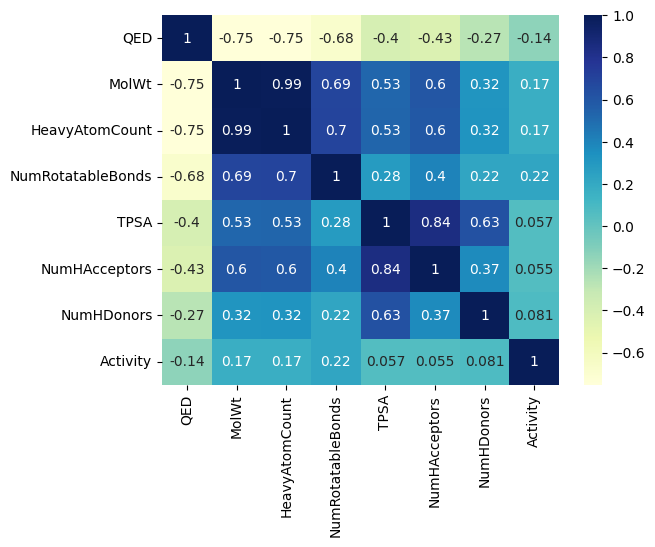

In [ ]:
# plotting correlation heatmap
dataplot = sns.heatmap(dp_ACHE.corr(), cmap="YlGnBu", annot=True)

# displaying heatmap
plt.show()

In [ ]:
# Nuevamente, igual que hicimos en clase vemos que hay una alta correlacion
# entre number of heavy atoms and the molecular mass asi que lo eliminamos.
dp_ACHE.drop(labels='HeavyAtomCount', axis=1, inplace=True)
dp_ACHE.head()

,QED,MolWt,NumRotatableBonds,TPSA,NumHAcceptors,NumHDonors,Activity
0,0.795789,243.350,2,20.31,2,0,1.0
1,0.834365,271.404,4,20.31,2,0,1.0
2,0.422541,208.281,2,26.30,2,0,0.0
3,0.603594,405.542,6,41.74,5,0,1.0
4,0.805692,236.267,3,44.76,4,0,1.0


# Clasificacion o regresion

In [ ]:
from sklearn.model_selection import train_test_split  # Para dividir dados em treino/teste

# split data in 80:20 for train:test dataset
X = dp_ACHE.iloc[:, :-1]  # Todas as linhas, todas as colunas exceto a última
y = dp_ACHE.iloc[:, -1]   # Todas as linhas, apenas a última coluna (target)

# In the first step we will split the data in training and remaining dataset
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


print(X_train.shape), print(y_train.shape)
print(X_test.shape), print(y_test.shape)

(4306, 6)
(4306,)
(1077, 6)
(1077,)


(None, None)

In [ ]:
# para evitar sesgos escalamos
from sklearn.preprocessing import *
sc = StandardScaler()

X_train = sc.fit_transform(X_train)

In [ ]:
X_test = sc.transform(X_test)
print(X_test)

[[ 0.98264198 -0.18615117 -0.99321926  0.44433114  0.73334013 -0.10728556]
 [-0.55771635  0.40248466  0.28751606 -0.21938839  0.73334013 -1.00084772]
 [ 0.35103778  0.62094787 -0.77976338  0.18417339  0.23644594 -0.10728556]
 ...
 [ 1.80090835 -0.94036722 -0.3528516  -0.66673281  0.23644594 -0.10728556]
 [-0.37772239  0.1735376  -0.13939572 -0.47002817 -0.75734245 -1.00084772]
 [ 0.65127266 -1.3553322  -0.77976338 -1.55317275 -1.75113083 -1.00084772]]


In [ ]:
# NO Usando Random Forest
# Usando Support Vector Machine
classifier = svm.SVC() #RandomForestClassifier(random_state=0)

classifier.fit(X_train, y_train)

SVC()

# Evaluacion

In [ ]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
def calc_metrics(labels_test, test_probs, threshold = 0.5):
    scores = [1 if x>=threshold else 0 for x in test_probs]
    auc = metrics.roc_auc_score(labels_test, test_probs, multi_class="ovr")
    kappa = metrics.cohen_kappa_score(labels_test,scores)
    confusion = metrics.confusion_matrix(labels_test,scores, labels=list(set(labels_test)))
    print('thresh: %.2f, kappa: %.3f, AUC test-set: %.3f'%(threshold, kappa, auc))
    print(confusion)
    print(metrics.classification_report(labels_test,scores,digits=3))
    return

In [ ]:
x_pred = classifier.predict(X_test)

In [ ]:
pd.DataFrame(x_pred).value_counts()

,count
0,
0.0,880
1.0,197


thresh: 0.50, kappa: 0.249, AUC test-set: 0.617
[[554  48]
 [326 149]]
              precision    recall  f1-score   support

         0.0      0.630     0.920     0.748       602
         1.0      0.756     0.314     0.443       475

    accuracy                          0.653      1077
   macro avg      0.693     0.617     0.596      1077
weighted avg      0.685     0.653     0.613      1077

None


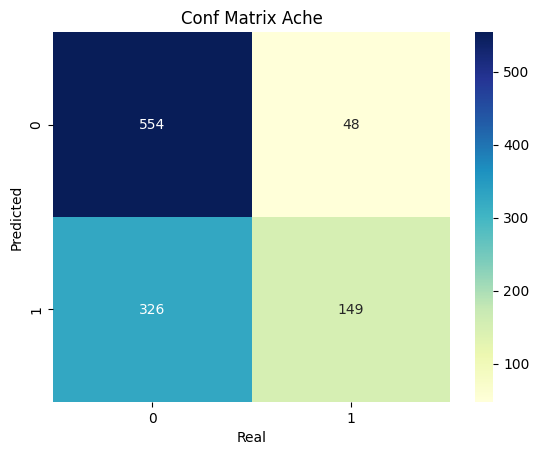

In [ ]:
print (calc_metrics(y_test, x_pred))

sns.heatmap(confusion_matrix(y_test, x_pred),cmap='YlGnBu' ,annot=True,fmt='2.0f')
plt.title('Conf Matrix Ache')
plt.ylabel('Predicted')
plt.xlabel('Real')
plt.show()

# fingerprints

In [ ]:
# Notamos que no esta funcionando realmente asi que probaremos con fingerprints
# de las notas de clase
def to_numpyarray_to_list(desc):
    arr = np.zeros((1,))
    DataStructs.ConvertToNumpyArray(desc, arr)
    return arr.tolist()

def calcula_fp1(dataframe):
    d={}
    c=0
    for x in dataframe:

        mol = Chem.MolFromSmiles(x)
        fp1 = rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, 20, nBits=2048)
        FP_as_BitVect = to_numpyarray_to_list(fp1)
        d['result{}'.format(c)] = FP_as_BitVect
        c+=1
    df = pd.DataFrame(d).transpose()
    return df

In [ ]:
fp_ACHE = calcula_fp1(smiles_ache_stand)
fp_ACHE

Streaming output truncated to the last 5000 lines.
[17:52:03] DEPRECATION WARNING: please use MorganGenerator
[17:52:03] DEPRECATION WARNING: please use MorganGenerator
[17:52:03] DEPRECATION WARNING: please use MorganGenerator
[17:52:03] DEPRECATION WARNING: please use MorganGenerator
[17:52:03] DEPRECATION WARNING: please use MorganGenerator
[17:52:03] DEPRECATION WARNING: please use MorganGenerator
[17:52:03] DEPRECATION WARNING: please use MorganGenerator
[17:52:03] DEPRECATION WARNING: please use MorganGenerator
[17:52:03] DEPRECATION WARNING: please use MorganGenerator
[17:52:03] DEPRECATION WARNING: please use MorganGenerator
[17:52:03] DEPRECATION WARNING: please use MorganGenerator
[17:52:03] DEPRECATION WARNING: please use MorganGenerator
[17:52:03] DEPRECATION WARNING: please use MorganGenerator
[17:52:03] DEPRECATION WARNING: please use MorganGenerator
[17:52:03] DEPRECATION WARNING: please use MorganGenerator
[17:52:03] DEPRECATION WARNING: please use MorganGenerator
[17:5

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
result0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
result1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
result2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
result3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
result4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
result5378,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
result5379,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
result5380,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
result5381,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Resetar índices antes de atribuir
fp_ACHE = fp_ACHE.reset_index(drop=True)
resultado = resultado.reset_index(drop=True)
fp_ACHE['Activity'] = resultado['Activity']
fp_ACHE.head()

,0,1,2,3,4,5,6,7,8,9,...,2039,2040,2041,2042,2043,2044,2045,2046,2047,Activity
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# Usando NaiveBayes
classifier = GaussianNB()

classifier.fit(X_train, y_train)
x_pred = classifier.predict(X_test)

thresh: 0.50, kappa: 0.205, AUC test-set: 0.599
[[484 118]
 [288 187]]
              precision    recall  f1-score   support

         0.0      0.627     0.804     0.705       602
         1.0      0.613     0.394     0.479       475

    accuracy                          0.623      1077
   macro avg      0.620     0.599     0.592      1077
weighted avg      0.621     0.623     0.605      1077

None


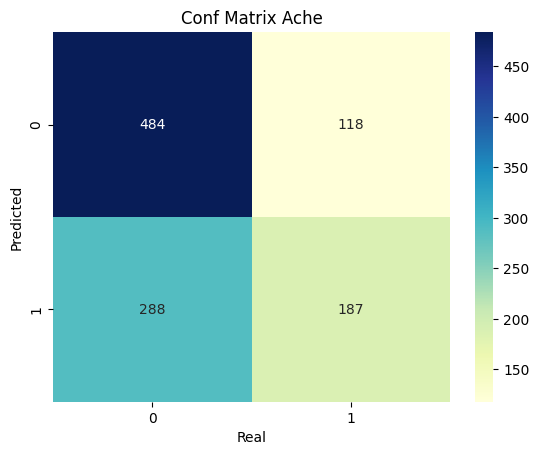

In [ ]:
print (calc_metrics(y_test, x_pred))

sns.heatmap(confusion_matrix(y_test, x_pred),cmap='YlGnBu' ,annot=True,fmt='2.0f')
plt.title('Conf Matrix Ache')
plt.ylabel('Predicted')
plt.xlabel('Real')
plt.show()

# Usando Chemberta

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch
from tqdm import tqdm  # Para barra de progresso


# 1. Carregar modelo e tokenizador
tokenizer = AutoTokenizer.from_pretrained("DeepChem/ChemBERTa-77M-MLM")
model = AutoModelForMaskedLM.from_pretrained("DeepChem/ChemBERTa-77M-MLM")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 2. Função para gerar embeddings
def get_molecule_embedding(smiles, model, tokenizer):
    inputs = tokenizer(smiles, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        last_hidden_state = outputs.hidden_states[-1]
        #return last_hidden_state[:,0,:].squeeze().cpu().numpy() #get the first row of embedding (classification token)
        return last_hidden_state.mean(dim=1).squeeze().cpu().numpy() #average values

# 3. Processar todos os SMILES (com barra de progresso)
embeddings = []
failed_smiles = []

for smile in tqdm(smiles_ache_stand, desc="Gerando embeddings"):
    try:
        if pd.isna(smile) or not smile:  # Pula valores nulos/vazios
            continue
        emb = get_molecule_embedding(smile, model, tokenizer)
        embeddings.append(emb)
    except Exception as e:
        failed_smiles.append(smile)
        continue

# 4. Converter para DataFrame
df_embeddings = pd.DataFrame(embeddings)
#df_embeddings['SMILES'] = [s for s in smiles_ache_stand if s not in failed_smiles]
df_embeddings['Activity'] = resultado['Activity']
print(f"\nEmbeddings gerados: {len(embeddings)}")
print(f"SMILES falhados: {len(failed_smiles)}")
print(f"Shape dos embeddings: {df_embeddings.shape}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.96k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/13.7M [00:00<?, ?B/s]

Gerando embeddings:   1%|          | 49/5383 [00:01<02:15, 39.50it/s]

model.safetensors:   0%|          | 0.00/13.7M [00:00<?, ?B/s]

Gerando embeddings: 100%|██████████| 5383/5383 [01:53<00:00, 47.58it/s]



Embeddings gerados: 5383
SMILES falhados: 0
Shape dos embeddings: (5383, 385)


In [ ]:
df_embeddings.head()

,0,1,2,3,4,5,6,7,8,9,...,375,376,377,378,379,380,381,382,383,Activity
0,-0.038857,0.003095,-0.007130,0.051530,0.144723,-0.024886,0.061918,0.090813,0.009441,0.120106,...,0.043924,-0.182801,0.091604,-0.025799,-0.154029,-0.004647,0.148159,0.056157,-0.093917,1.0
1,-0.061092,-0.047996,-0.033261,0.057001,0.127676,-0.018489,0.029460,0.039060,-0.020183,0.108201,...,0.002757,-0.160093,0.079709,-0.045602,-0.219480,-0.044654,0.124704,0.078738,-0.075095,1.0
2,0.024234,-0.018762,-0.075961,0.140852,0.069428,-0.020260,0.045222,0.195928,-0.012099,0.124575,...,0.142349,-0.106740,-0.021900,0.009384,-0.119566,0.101987,0.070984,0.141574,-0.289655,0.0
3,0.053842,-0.134951,-0.011490,0.017317,0.077888,0.009328,0.064008,0.204522,-0.050462,0.049877,...,0.071273,-0.114471,0.158754,-0.010997,-0.196422,0.091217,0.118475,-0.061124,-0.053348,1.0
4,-0.114140,-0.012006,-0.030179,0.057491,-0.079374,0.064951,0.001323,0.068954,0.094713,0.029451,...,0.280485,0.093627,-0.029247,0.098105,-0.179614,0.098746,0.075817,0.183253,-0.146309,1.0


In [ ]:
# split data in 80:20 for train:test dataset
X = df_embeddings.iloc[:, :-1]  # Todas as linhas, todas as colunas exceto a última
y = df_embeddings.iloc[:, -1]   # Todas as linhas, apenas a última coluna (target)

# In the first step we will split the data in training and remaining dataset
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(X_train.shape), print(y_train.shape)
print(X_test.shape), print(y_test.shape)

(4306, 384)
(4306,)
(1077, 384)
(1077,)


(None, None)

In [ ]:
# Probando nuevamente con SVM
classifier = svm.SVC()

classifier.fit(X_train, y_train)
x_pred = classifier.predict(X_test)

thresh: 0.50, kappa: 0.474, AUC test-set: 0.730
[[533  69]
 [202 273]]
              precision    recall  f1-score   support

         0.0      0.725     0.885     0.797       602
         1.0      0.798     0.575     0.668       475

    accuracy                          0.748      1077
   macro avg      0.762     0.730     0.733      1077
weighted avg      0.757     0.748     0.740      1077

None


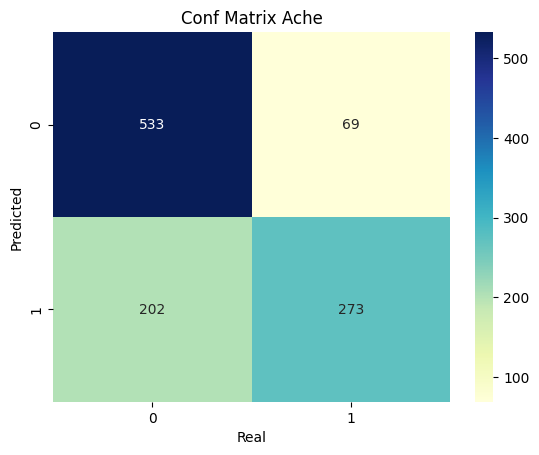

In [ ]:
print (calc_metrics(y_test, x_pred))

sns.heatmap(confusion_matrix(y_test, x_pred),cmap='YlGnBu' ,annot=True,fmt='2.0f')
plt.title('Conf Matrix Ache')
plt.ylabel('Predicted')
plt.xlabel('Real')
plt.show()

In [ ]:
# Observamos que naive bayes funcono bastante bien con fingerprints
# en comparacion con propiedades moleculares con SVM
#  y/o chemberta independientemente del clasificador.